# Umělý život

Umělý život se zabývá systémy, které připomínají skutečný život. Jejich cílem je pochopit, jak organismy fungují, komunikují a chovají se. Snaží se toto chování vytvořit a napodobovat pomocí programů. Na dnešním cvičení si zkusíme některé z těchto technik nasimulovat a podívat se na jejich chování.

In [1]:
import matplotlib.pyplot as plt

##  Celulární automaty

Celulární automaty jsou (typicky) 1D nebo 2D mřížky, kde každé políčko může mít jednu z *k* barev, v nejjednodušším případě jsou barvy jen dvě, což značí že na některých políčkách organismus je a na jiných ne. Na základě barvy políčka a jeho sousedů do dané vzdálenosti se potom definují pravidla pro změny barev políček. Praktické využití celulárních automatů může být například při simulaci šíření požáru nebo pohyb aut ve vozovce.

Zkusíme si tedy jednoduchý celulární automat se 2 barvami nasimulovat. K tomu použijeme knihovnu [cellpylib](https://libraries.io/pypi/cellpylib), kde je celulární automat už naprogramovaný.

In [2]:
import cellpylib as cpl

Nejprve nainicializujeme jedince délky 100, který bude mít všude samé 0 a uprostřed jednu 1.

In [3]:
ca = cpl.init_simple(100)

Dále definujeme pravidlo, jak se bude každá trojice znaků přepisovat na další řádek níž. (To funguje tak, že vytvoříme binární řetězec délky 8, kde každá pozice *p* (0 standardně v řetězci napravo, 7 nalevo) odpovídá trojcifernému binárnímu číslu *b* kódujícímu tuto pozici. V každé iteraci se pak každý znak v novém jedinci vygeneruje na základě znaku na stejném místě v původním jedinci a jeho sousedů. Tyto tři znaky mi spolu dají právě trojciferné *b*, a v novém jedinci bude znak z našeho pravidla na pozici *p* příslušející k danému *b*. Ergo označíme-li starého jedince *old*, nového *new* a naše pravidlo (binární řetězec znaků) jako *rule*, pak pro každou pozici *i* v jedincích platí: *new*\[*i*\] = *rule*\[integer(*old*\[*i*-1:*i*+2\])\])

Následně si pro názornost přehledně vypíšeme, na co se jednotlivé trojice přepisují. K tomu se bude hodit funkce `bin`, která vrací binární ekvivalent čísla jako string. (První dvě pozice zahodíme, protože na nich je jen prefix *0b* symbolizující binární zápis čísla.) Pak musíme ještě doplnit případné chybějící nuly, k čemuž využijeme metodu stringu `zfill`.

In [4]:
# Rule definition
rule_number = 0b10011110
print('Rule number: ' + str(rule_number))

# Rule explanation
rule_number_binary = bin(rule_number)[2:].zfill(8)
rule_triples = ['111','110','101','100','011','010','001','000']
for i, b in enumerate(rule_number_binary):
    print(rule_triples[i], '->', b)

Rule number: 158
111 -> 1
110 -> 0
101 -> 0
100 -> 1
011 -> 1
010 -> 1
001 -> 1
000 -> 0


Spustíme běh (evoluci) celulárního automatu s naším pravidlem.

In [5]:
ca = cpl.evolve(ca, timesteps=50, apply_rule=lambda n, c, s: cpl.nks_rule(n, rule_number))

Nakonec si vykreslíme vzniklý obrázek - a protože knihovna `cpl.plot` používá na pozadí `matplotlib`, můžeme si speficikovat jeho rozměry nám známým způsobem.

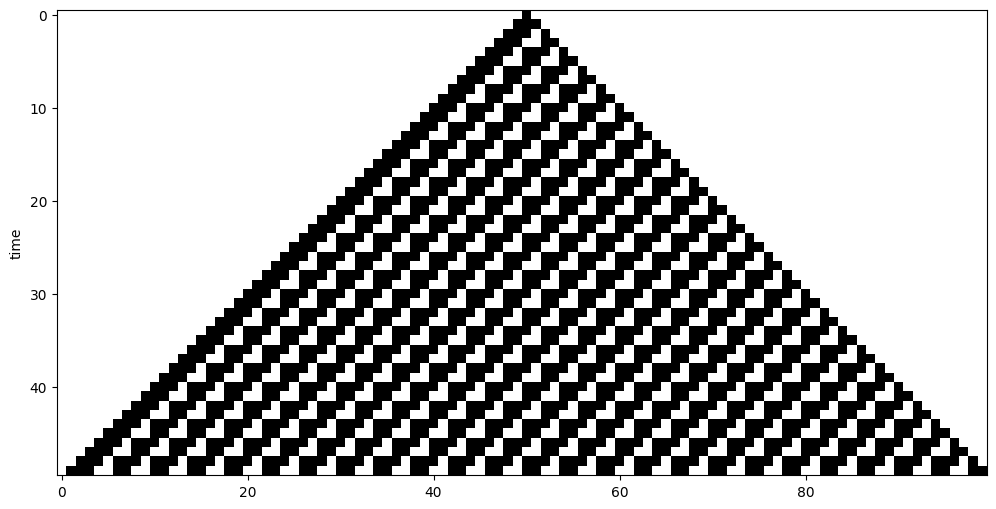

In [6]:
plt.figure(figsize=(12,8))
cpl.plot(ca)

### Úkol na cvičení 1
Zkuste si pohrát s nastavením pravidel tak, abyste našli automat, který vygeneruje nějaké zajímavé obrazce (šachovnici, rovné čáry, [Sierpinskeho trojúhelník](https://cs.wikipedia.org/wiki/Sierpi%C5%84sk%C3%A9ho_troj%C3%BAheln%C3%ADk), nebo libovolné jiné).

## Convay's Game of Life

Game of Life je jedním z nejznámějších celulárních 2D automatů, kde nová hodnota každého políčka závisí na všech okolních políčkách. Pravidla jsou jednoduchá:
1. živá buňka s méně než dvěma nebo více než třemi živými sousedy umírá
2. živá buňka s dvěma nebo třemi živými sousedy přežívá
3. mrtvá buňka s právě třemi živými sousedy ožívá

Na základě těchto velmi jednoduchých pravidel se dají implementovat docela zajímavé organismy, které se množí, pohybují apod. To si vyzkoušíme za pomoci knihovny [seagull](https://pyseagull.readthedocs.io/en/latest/index.html). (Instalace: `pip install pyseagull`)

In [7]:
plt.rcParams["animation.html"] = "jshtml"

import seagull as sg
import seagull.lifeforms as lf

import numpy as np
np.product = np.prod
# Seagull is silently relying on an older numpy version, where np.product method existed side-by-side with np.prod.
# They were doing basically the same, the np.product was later even just an alias for np.prod.
# However, in newer numpy versions, np.product was designated as deprecated and is missing.
# We fix this by recreating np.product as an alias for np.prod method.

Vytvoříme si prostředí o dané velikosti a potom do něj přidáme oscilátor, což je vzor / tvar, který se po nějaké době vrátí do původního stavu, tedy cyklí svou evoluci. Existuje pár už předdefinovaných oscilátorů - například Pulsar, Glider a Blinker. Tak je tam nacpěme všechny a pojďme se podívat na animaci, jak se to bude chovat.

2026-05-06 14:14:52.297 | INFO     | seagull.simulator:compute_statistics:128 - Computing simulation statistics...
2026-05-06 14:14:52.301 | INFO     | seagull.simulator:animate:183 - Rendering animation...


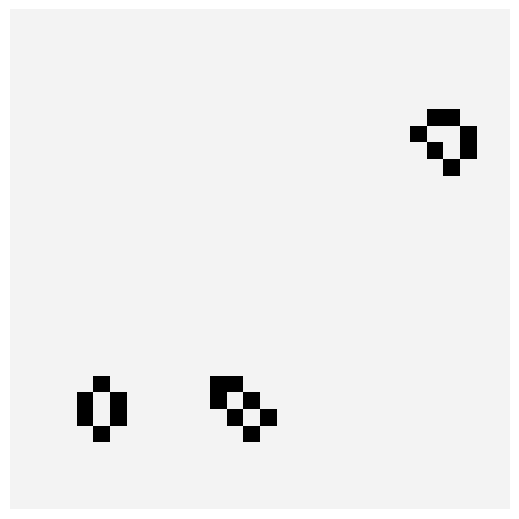

In [8]:
# Initialize the space
board = sg.Board(size=(30,30))

# Add three different "living entities" - oscilators
board.add(lf.Glider(), loc=(15,4))
board.add(lf.Pulsar(), loc=(5,12))
board.add(lf.Blinker(length=4), loc=(22,5))

# Run the simulation
sim = sg.Simulator(board)
sim.run(sg.rules.conway_classic, iters=150)

# Render the animation of our simulation
sim.animate()

V následujícím [videu](https://www.youtube.com/watch?v=3NDAZ5g4EuU) se pro zajímavost můžete podívat, že pomocí Game of Life se dají při troše (hodně) kreativity a úsilí vyrobit i klasické digitální hodiny. Navíc Game of Life je Turingovsky úplná, což znamená, že je ekvivalentní Turigovu stroji, takže na ní dokážeme spočítat úplně cokoli. Teoreticky...

Na závěr [zde](https://bitstorm.org/gameoflife/) můžeme zkoumat simulace všemožných jednoduchých (a ne až tak jednoduchých) oscilátorů.

### Úkol na cvičení 2

Vyzkoušejte si i vlastní organismy v Game of Life. Najdete nějaké, které se chovají zajímavě? Vlastní organismus můžete definovat pomocí `lf.Custom`, jako parametr zadáte 2D pole 0 a 1. Dále si můžete hrát s různými velikostmi boardu a s různými počátečními pozicemi a sledovat, co se bude dít.

## Langton's Ant

Langtonův mravenec představuje další velmi jednoduchou simulaci života. Jde o mravence, který se pohybuje na mřížce se dvěma barvami. Při každém pohybu přebarví svoje políčko na opačnou barvu. V závislosti na počáteční barvě políčka se potom rozhoduje, jestli má jít doleva, nebo doprava.

Implementaci Langtonových mravenců si ukážeme v prostředí [NetLogo](http://ccl.northwestern.edu/netlogo/index.shtml), které se pro podobné simulace často používá. Pro základní funkcionalitu ani nemusíme tento nástroj stahovat a ukážeme si vše ve verzi pro prohlížeč, kterou najdeme [zde](http://www.netlogoweb.org/). (Pro vytvoření modelu Langtonova mravence a pro naučení se s NetLogem můžeme případně využít následující [tutoriál](https://www.cs.unm.edu/~joel/cs4all/langtons-ant.pdf).)

### Úkol na cvičení 3

Seznamte se (v případě zájmu) s prostředím [NetLogo](http://ccl.northwestern.edu/netlogo/index.shtml) tak, že si projdete výše zmíněný [tutoriál](https://www.cs.unm.edu/~joel/cs4all/langtons-ant.pdf) a zimplementujete si tam popsaného Langtonova mravence.